In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive
drive.mount('/content/drive')
titanic = pd.read_csv('/content/drive/MyDrive/dane/titanic.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Braki stanowią aż 78% kolumn dotyczących przydzielenia pasażerów do kabin, więc zastąpimy ją kolumną określającą czy dany pasażer został przydzielony do jakiejkolwiek kabiny czy też nie/nie wiadomo.

In [2]:

titanic['Has_Cabin'] = titanic['Cabin'].notna().astype(int)
titanic = titanic.drop(columns=['Cabin'])

Teraz kodujemy płeć, if female: sex = 0, man: sex = 1

In [3]:
titanic['Sex'] = titanic['Sex'].map({
    'male': 1, 'female': 0
})

Kodujemy kolumnę embarked za pomocą one-hot encoding, ponieważ dane porty nie mają między sobą żadnego naturalnego porządku, oraz wypełniamy braki najczęstszą wartością.

In [4]:
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
titanic = pd.get_dummies(titanic, columns=['Embarked'], prefix='Embarked', dtype=int)


Braki wiekowe możemy uzupełnić przewidując na podstawie podanych danych zgodnie z rozkładem

In [5]:
age = titanic['Age'].dropna()
titanic['Age'] = titanic['Age'].apply(lambda x: np.random.choice(age) if pd.isna(x) else x)


Kolumnę Fare uzupełnimy medianą, ponieważ rozkład jest asymetryczny. Najczęstszym zakupionym biletem jest ten z klasy trzeciej, najrzadziej z klasy pierwszej. Liczymy medianę cen dla poszczególnej klasy i przypisujemy brakom tą cenę.

In [6]:
titanic['Fare'] = titanic['Fare'].fillna(
    titanic.groupby('Pclass')['Fare'].transform('median')
)

Podejmuję decyzję o usunięciu kolumny 'Ticket', 'Name' oraz 'PassengerId', ponieważ nie jestem w stanie odpowiednio zakodować tych kolumny i nie uważam by te kolumny niosły wartość istotną dla dalszej analizy. Traktuję je jako zbędne.

In [7]:
titanic = titanic.drop(columns=['Ticket', 'Name', 'PassengerId'])

Liczymy członków pojedynczej rodziny sumując ze sobą 'SibSp' oraz 'Parch', zastępujemy nią te dwie kolumny oraz skalujemy minmaxem

In [8]:
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
titanic = titanic.drop(columns=['SibSp', 'Parch'])


Age oraz FamilySize skalujemy minmaxem, a Fare najpierw za pomocą logarytmu zamiast od razu minmax, dzięki temu unikniemy sytuacji, że znaczna większość wierszy uzyska bardzo niską wartość, a tylko pojedyncze tą maksymalną.

In [10]:
titanic['Fare'] = np.log1p(titanic['Fare'])
titanic[['Age', 'Fare', 'FamilySize']] = MinMaxScaler().fit_transform(titanic[['Age', 'Fare', 'FamilySize']])

Prezentacja tabeli

In [11]:
display(titanic)

,Survived,Pclass,Sex,Age,Fare,Has_Cabin,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,0,3,1,0.271174,0.573149,0,0,0,1,0.1
1,1,1,0,0.472229,0.840530,1,1,0,0,0.1
2,1,3,0,0.321438,0.585763,0,0,0,1,0.0
3,1,1,0,0.434531,0.812024,1,0,0,1,0.1
4,0,3,1,0.434531,0.587961,0,0,0,1,0.0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,0.334004,0.652469,0,0,0,1,0.0
887,1,1,0,0.233476,0.752267,1,0,0,1,0.0
888,0,3,0,0.057552,0.724477,0,0,0,1,0.3
889,1,1,1,0.321438,0.752267,1,1,0,0,0.0


Tworzymy heatmapę i widzimy, że większą szansę na przeżycie miały osoby z pierwszej klasy oraz płci żeńskiej. Widzimy też, że osoby które miały przydzieloną wartość 'Cabin' w większości posiadały bilety do klasy pierwszej.

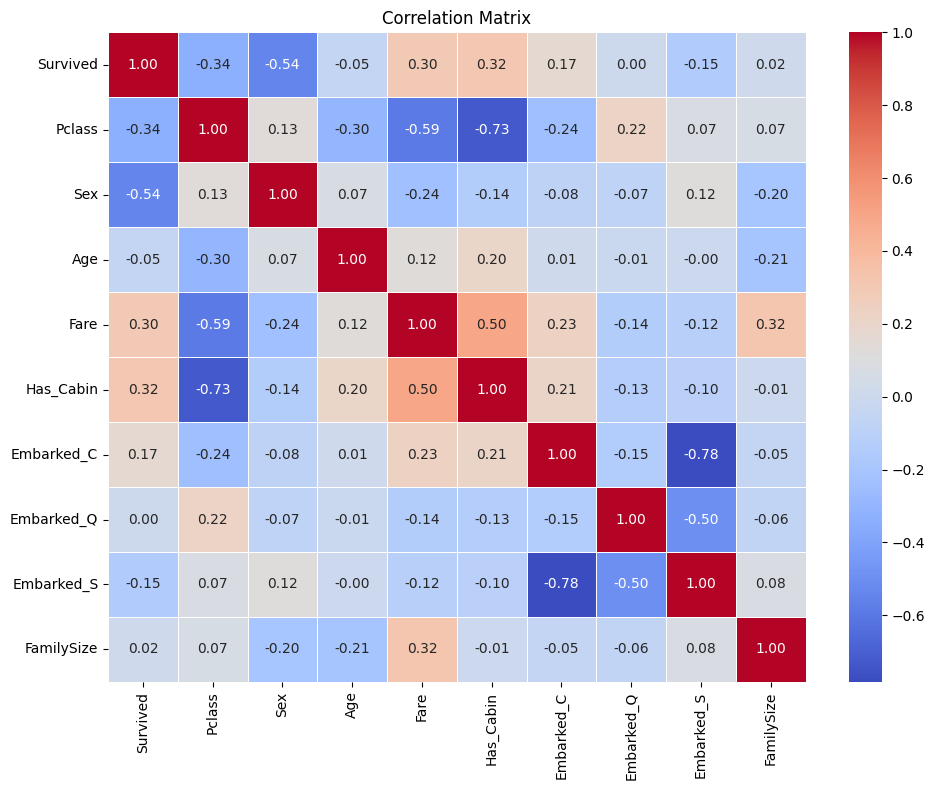

In [12]:
def plot_correlation_matrix(df):
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()
plot_correlation_matrix(titanic)

Boxplot z outlierami numerycznych kolumn

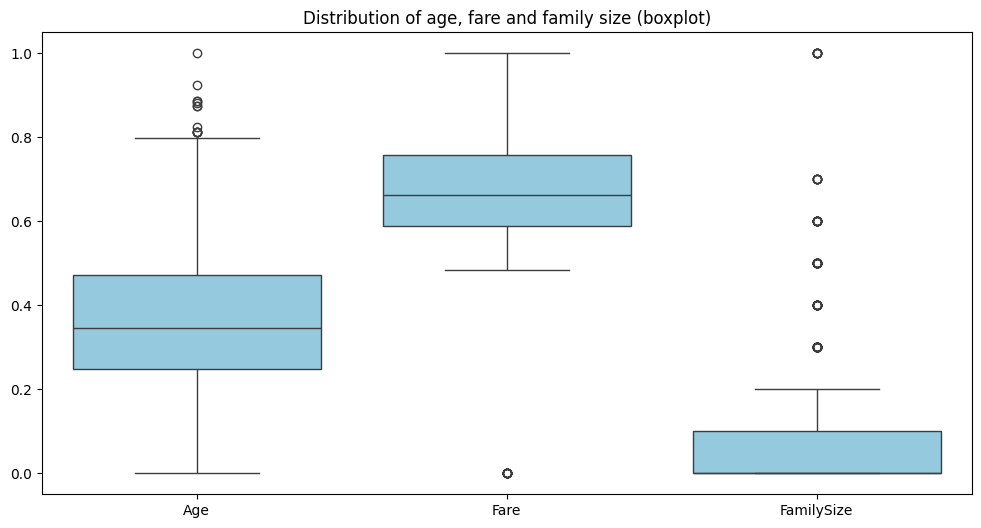

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=titanic[['Age', 'Fare', 'FamilySize',]], color='skyblue')
plt.title(f"Distribution (boxplot)")
plt.show()

Wykres słupkowy z kategorycznych kolumn, bardzo niski słupek świadczy o outlierze, np Embarked C i Q oraz Has_Cabin

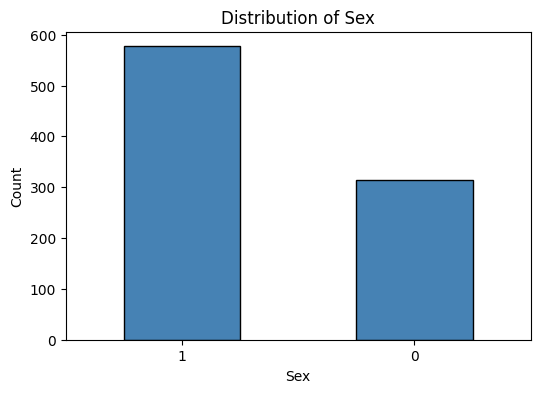

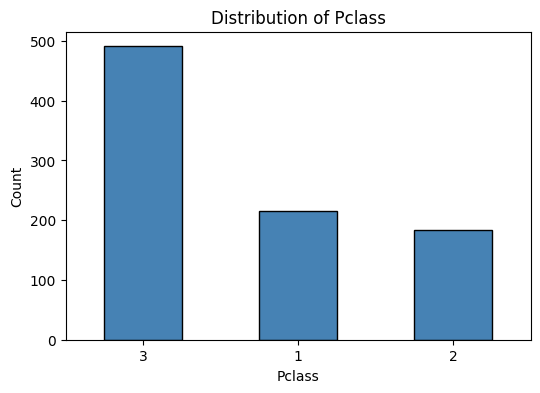

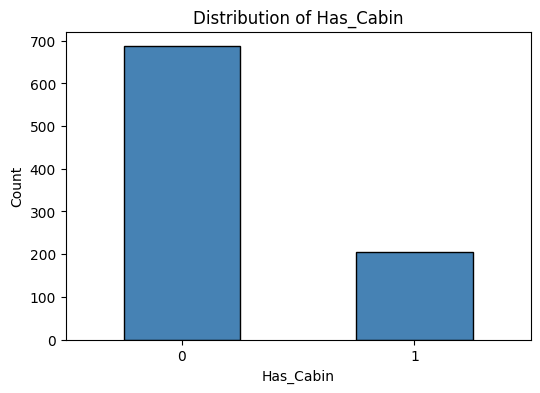

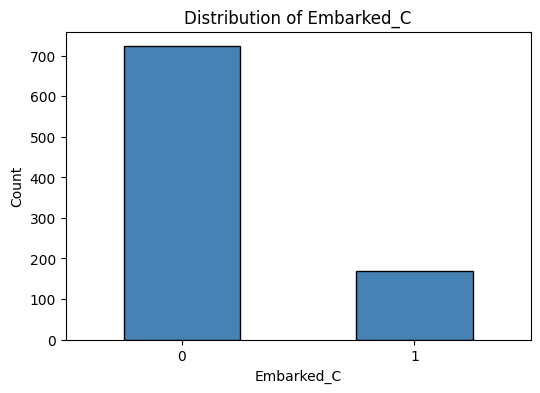

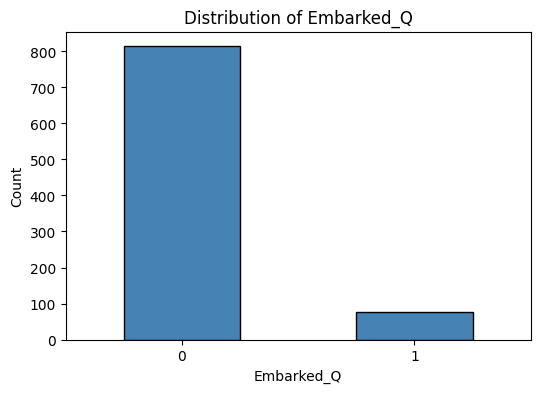

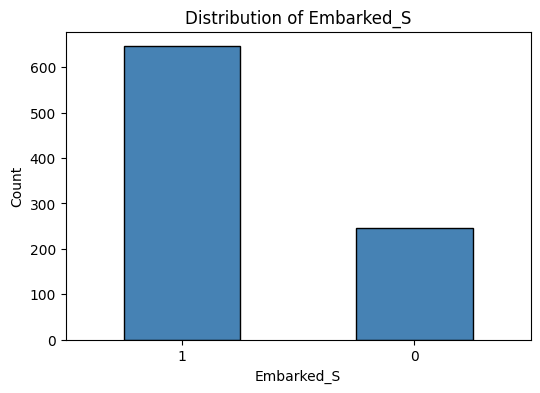

In [21]:
def plot_categorical_column(df, column_name):
  counts = df[column_name].value_counts()
  plt.figure(figsize=(6, 4))
  counts.plot(kind='bar', color='steelblue', edgecolor='black')
  plt.title(f'Distribution of {column_name}')
  plt.xlabel(column_name)
  plt.ylabel('Count')
  plt.xticks(rotation=0)
  plt.show()
categorical_cols = ['Sex', 'Pclass', 'Has_Cabin', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
for col in categorical_cols:
    plot_categorical_column(titanic, col)